## Day 17 PCA
## Mikel Good

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("data_files/Adult_Tobacco_Consumption_US.csv")
df["Total"] = df["Total"].str.replace(",", "")
df["Total"] = df["Total"].astype(int)
df.head()

,Year,LocationAbbrev,LocationDesc,Population,Topic,Measure,Submeasure,Data Value Unit,Domestic,Imports,Total,Domestic Per Capita,Imports Per Capita,Total Per Capita
0,2000,US,National,"209,786,736",Noncombustible Tobacco,Smokeless Tobacco,Chewing Tobacco,Pounds,"45,502,156","91,965",45594121,0.217,0.0,0.217
1,2000,US,National,"209,786,736",Combustible Tobacco,Cigarettes,Cigarette Removals,Cigarettes,"423,250,355,675","12,319,663,000",435570018675,"2,018",59.0,"2,076"
2,2000,US,National,"209,786,736",Combustible Tobacco,Cigars,Total Cigars,Cigars,"5,612,867,329","548,243,000",6161110329,27,3.0,29
3,2000,US,National,"209,786,736",Combustible Tobacco,Loose Tobacco,Total Loose Tobacco,Cigarette Equivalents,"8,291,276,800","702,741,662",8994018462,40,3.0,43
4,2000,US,National,"209,786,736",Combustible Tobacco,Loose Tobacco,Total Loose Tobacco,Pounds,"16,841,656","1,427,444",18269100,0,0.0,0


In [7]:
comb_tots = {}
non_comb_tots = {}

for _, row in df.iterrows():
    year = row["Year"]
    typ = row["Topic"]
    tot = row["Total"]

    if typ == "Noncombustible Tobacco":
        if year not in non_comb_tots:
            non_comb_tots[year] = tot
        else:
            non_comb_tots[year] += tot

    else:
        if year not in comb_tots:
            comb_tots[year] = tot
        else:
            comb_tots[year] += tot

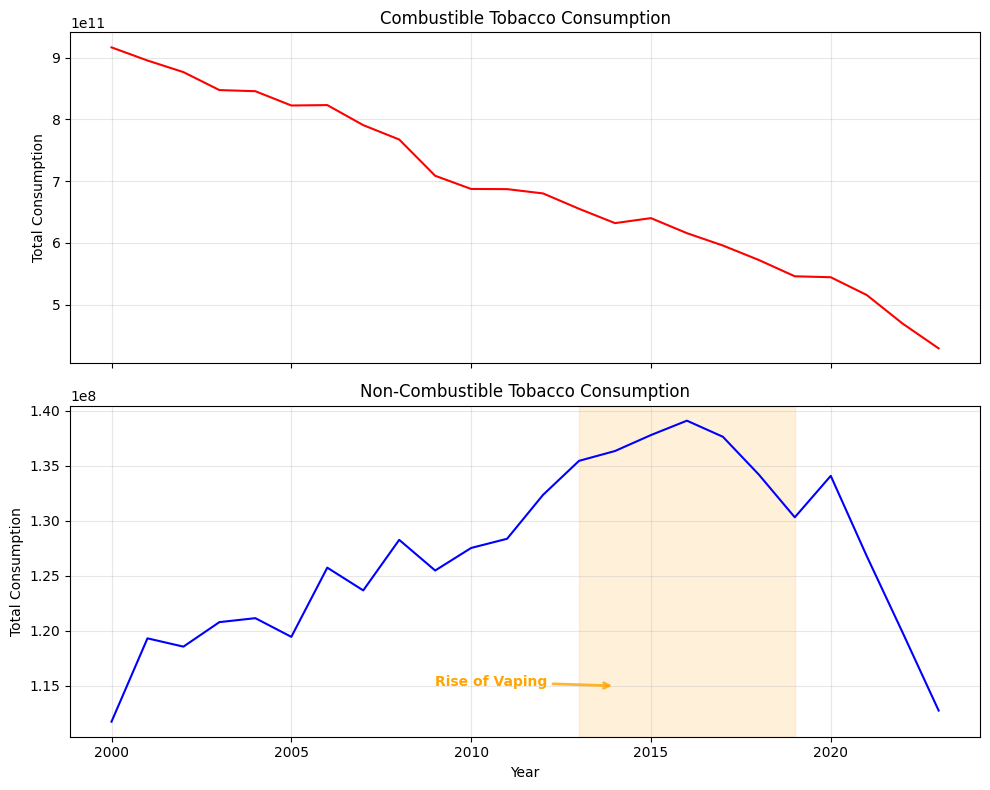

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(list(comb_tots.keys()), list(comb_tots.values()), color='red')
axes[0].set_title("Combustible Tobacco Consumption")
axes[0].set_ylabel("Total Consumption")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(non_comb_tots.keys()), list(non_comb_tots.values()), color='blue')
axes[1].set_title("Non-Combustible Tobacco Consumption")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Total Consumption")
axes[1].grid(True, alpha=0.3)

axes[1].axvspan(2013, 2019, color='orange', alpha=0.15)
axes[1].annotate("Rise of Vaping", xy=(2014, 1.15e8), xytext=(2009, 1.15e8), color="orange",
                 fontweight="bold", fontsize=10,
                arrowprops=dict(arrowstyle="->", color="orange", lw=2, alpha=0.8))

plt.tight_layout()
plt.savefig("output_files/US_Tobacco_Trends.png", dpi=400)
plt.show()